In [1]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
print(df.shape)

(284807, 31)


In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

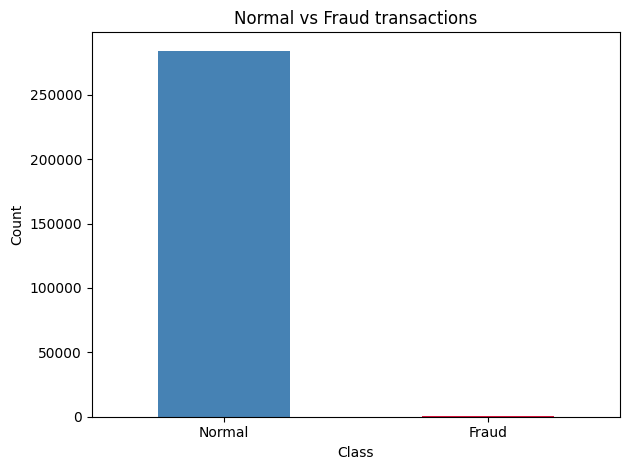

In [4]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Normal vs Fraud transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_balance.png')
plt.show()

Average fraud transaction amount: 122.21
Average normal transaction amount: 88.29


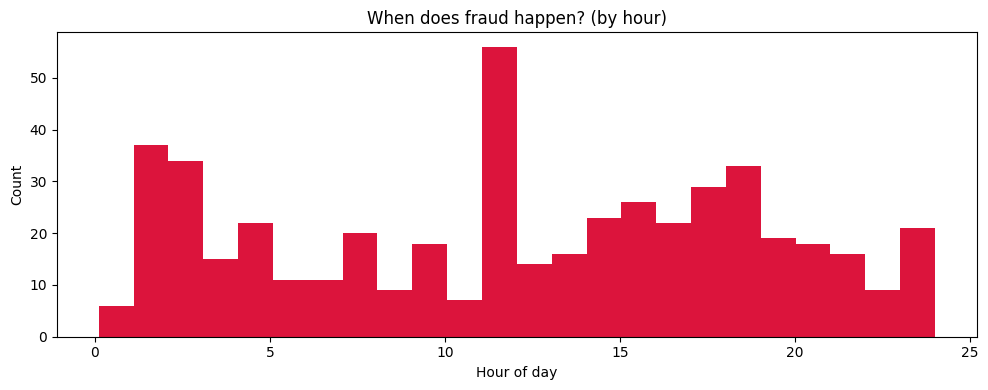

In [5]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print('Average fraud transaction amount:', round(fraud['Amount'].mean(), 2))
print('Average normal transaction amount:', round(normal['Amount'].mean(), 2))
fraud_hours = (fraud['Time'] / 3600) % 24
normal_hours = (normal['Time'] / 3600) % 24

plt.figure(figsize=(10, 4))
plt.hist(fraud_hours, bins=24, color='crimson')
plt.xlabel('Hour of day')
plt.ylabel('Count')
plt.title('When does fraud happen? (by hour)')
plt.tight_layout()
plt.savefig('fraud_hours.png')
plt.show()

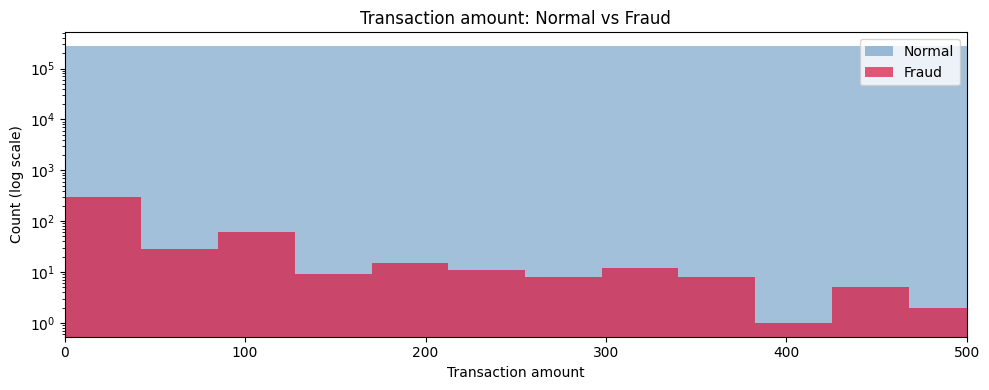

In [6]:
plt.figure(figsize=(10, 4))
plt.hist(normal['Amount'], bins=50, alpha=0.5, color='steelblue', label='Normal')
plt.hist(fraud['Amount'], bins=50, alpha=0.7, color='crimson', label='Fraud')
plt.xlabel('Transaction amount')
plt.ylabel('Count (log scale)')
plt.title('Transaction amount: Normal vs Fraud')
plt.xlim(0, 500)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('amount_distribution.png')
plt.show()

In [7]:
import sqlite3

conn = sqlite3.connect('transactions.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print('Done')

Done


In [8]:
query = """
SELECT Class, COUNT(*) as count, ROUND(AVG(Amount), 2) as avg_amount
FROM transactions
GROUP BY Class
"""

result = pd.read_sql(query, conn)
print(result)

   Class   count  avg_amount
0      0  284315       88.29
1      1     492      122.21


In [9]:
query2 = """
SELECT ROUND(Time / 3600 % 24) as hour, COUNT(*) as fraud_count
FROM transactions
WHERE Class = 1
GROUP BY hour
ORDER BY fraud_count DESC
LIMIT 5
"""

result2 = pd.read_sql(query2, conn)
print(result2)

   hour  fraud_count
0   2.0           57
1  11.0           53
2  18.0           33
3  17.0           29
4  15.0           26


In [10]:
query3 = """
SELECT 
    CASE 
        WHEN Amount < 10 THEN 'Under 10'
        WHEN Amount < 100 THEN '10 to 100'
        WHEN Amount < 500 THEN '100 to 500'
        ELSE 'Over 500'
    END as amount_range,
    COUNT(*) as fraud_count
FROM transactions
WHERE Class = 1
GROUP BY amount_range
ORDER BY fraud_count DESC
"""

result3 = pd.read_sql(query3, conn)
print(result3)

  amount_range  fraud_count
0     Under 10          249
1    10 to 100          113
2   100 to 500           95
3     Over 500           35


In [11]:
query4 = """
SELECT 
    ROUND(Time / 3600 % 24) as hour,
    ROUND(AVG(Amount), 2) as avg_fraud_amount,
    COUNT(*) as fraud_count
FROM transactions
WHERE Class = 1
GROUP BY hour
ORDER BY avg_fraud_amount DESC
LIMIT 5
"""

result4 = pd.read_sql(query4, conn)
print(result4)

   hour  avg_fraud_amount  fraud_count
0   0.0            303.34            6
1  10.0            293.70            8
2  16.0            204.79           22
3  12.0            200.38           17
4  18.0            192.28           33


In [12]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.58      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



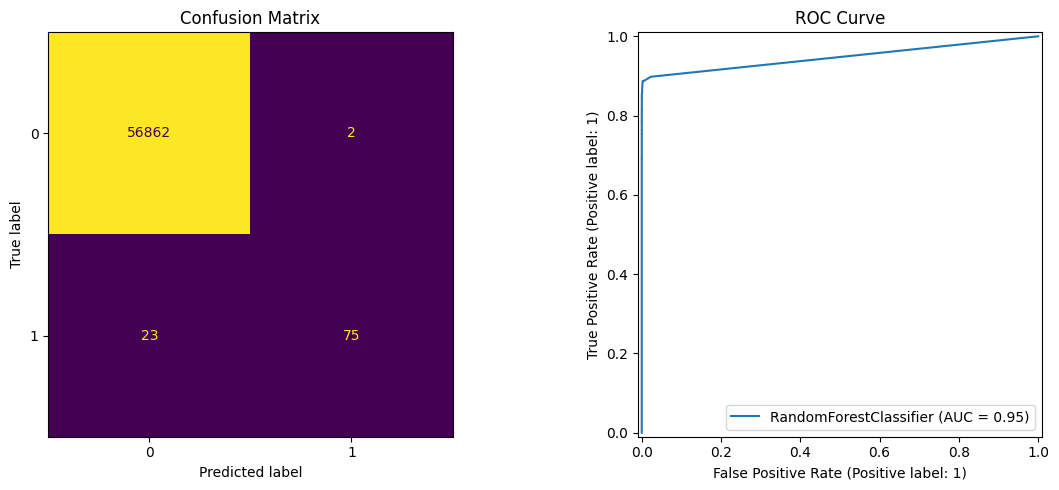

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(model_rf, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig('model_results.png')
plt.show()